<a href="https://colab.research.google.com/github/fahad15fede/Assignment-AI-ML/blob/main/Linear_and_Polynomial_Regression(student_performance).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Student_Performance.csv')

In [ ]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Checking Missing Rows

In [ ]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


### Checking Duplicated Rows

In [ ]:
df.duplicated().sum()

np.int64(127)

In [ ]:
df.drop_duplicates(inplace=True)
print(f"Shape of the dataset after removing duplicates: {df.shape}")

Shape of the dataset after removing duplicates: (9873, 6)


In [ ]:
df.shape

(9873, 6)

### Separating Categorical and Numerical Columns

In [ ]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

# Identify categorical and numerical features
categorical_features = ['Extracurricular Activities']
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

Categorical features: ['Extracurricular Activities']
Numerical features: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']


### Creating Column Transformer and Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### Training Model and Evaluating Model

Linear Regression MSE: 4.31
Linear Regression R2 Score: 0.99


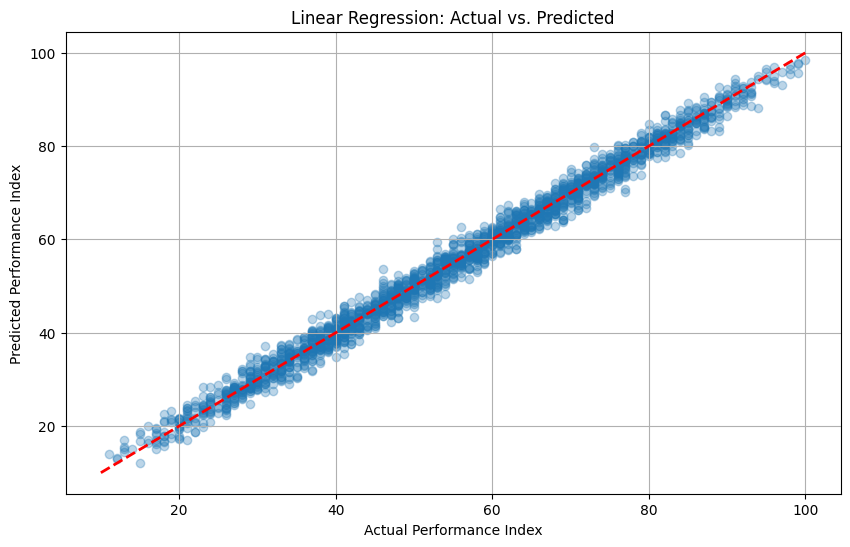

Linear Regression model saved as 'linear_regression_model.pkl'


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import numpy as np

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Linear Regression pipeline
linear_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
linear_reg_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = linear_reg_pipeline.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MSE: {mse_lr:.2f}")
print(f"Linear Regression R2 Score: {r2_lr:.2f}")

# Plotting Actual vs Predicted values for Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Linear Regression: Actual vs. Predicted')
plt.grid(True)
plt.show()

# Save the Linear Regression model
joblib.dump(linear_reg_pipeline, 'linear_regression_model.pkl')
print("Linear Regression model saved as 'linear_regression_model.pkl'")

### Applying Polynomial Regression

Polynomial Regression MSE: 4.31
Polynomial Regression R2 Score: 0.99


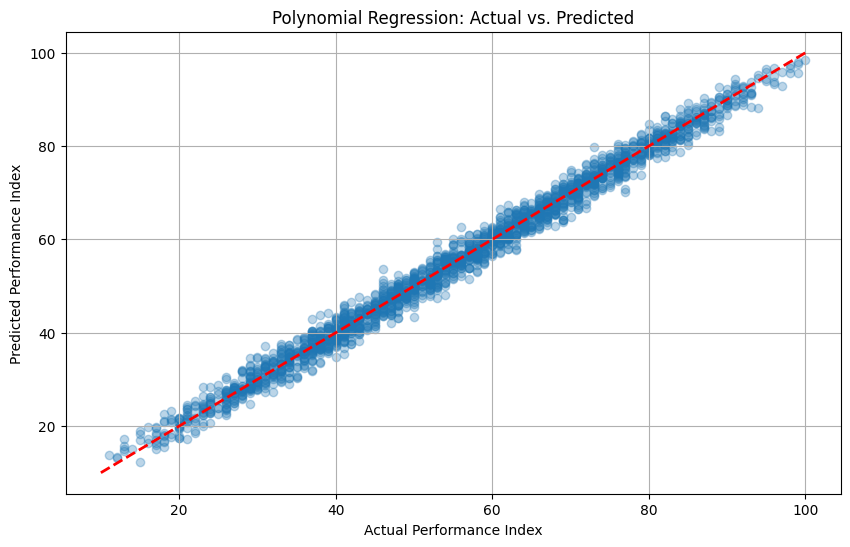

Polynomial Regression model saved as 'polynomial_regression_model.pkl'


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create the Polynomial Regression pipeline (degree 2)
poly_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

# Train the model
poly_reg_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_poly = poly_reg_pipeline.predict(X_test)

# Evaluate the model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression MSE: {mse_poly:.2f}")
print(f"Polynomial Regression R2 Score: {r2_poly:.2f}")

# Plotting Actual vs Predicted values for Polynomial Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Polynomial Regression: Actual vs. Predicted')
plt.grid(True)
plt.show()

# Save the Polynomial Regression model
joblib.dump(poly_reg_pipeline, 'polynomial_regression_model.pkl')
print("Polynomial Regression model saved as 'polynomial_regression_model.pkl'")